# Week 14 - Learning turbulence closures without losing the physics

**Lars Davidson / pyCALC-RANS research workflow; FlowMLLab teaching adaptation.**
Instructor: Ehsan Roohi. DNS: Myoungkyu Lee and Robert D. Moser.

This notebook corrects the supplied audit's baseline labeling and distinguishes
three things: **the original NN training protocol**, a **FlowMLLab interpolation
control**, and **retained fresh executions of the original CFD solver**.
It is not Davidson's original notebook or a new blind research benchmark.

The companion review documents the exact differences from the supplied notebook.
Read [the 2026 primary paper](https://arxiv.org/abs/2511.12493v3) and
[the code-update notes](https://www.cfd-sweden.se/lada/Using-Physical-Informed-Neural-Network-PINN-and-NN-improve-a-k-omega-turbulence-model.html).

**Run All:** CPU; dependencies NumPy, SciPy, pandas, matplotlib, scikit-learn,
PyTorch. Run from a complete FlowMLLab checkout. The small original-network
training is repeated. Expensive CFD and inverse-PINN executions are separate
commands; the notebook verifies and reads their retained evidence, not silently
relabeling saved results as fresh executions.

In [1]:
from pathlib import Path
import hashlib, json, platform, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display, Image
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'results/week14_validation/teaching_data.npz').exists()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook in a complete FlowMLLab checkout.')
EVIDENCE = ROOT / 'results/week14_validation'
manifest = json.loads((EVIDENCE / 'manifest.json').read_text())
for name, sha in manifest['files'].items():
    assert hashlib.sha256((EVIDENCE / name).read_bytes()).hexdigest() == sha, name
data = np.load(EVIDENCE / 'teaching_data.npz', allow_pickle=False)
dns, stress = data['dns'], data['stress']
baseline, corrected = data['baseline_archive'], data['corrected_archive']
target = data['ck']
torch.set_num_threads(1)
torch.manual_seed(42)
np.random.seed(42)
plt.rcParams.update({'font.size':11, 'axes.spines.top':False,
                     'axes.spines.right':False, 'figure.figsize':(9,4)})
print({'python':platform.python_version(), 'numpy':np.__version__,
       'torch':torch.__version__, 'seed':42, 'evidence_files_verified':len(manifest['files'])})

{'python': '3.12.14', 'numpy': '2.5.3', 'torch': '2.14.0+cpu', 'seed': 42, 'evidence_files_verified': 24}


## 1. Identify the real baseline before comparing errors

The supplied notebook's table is from the PINN-corrected case, not the classical
unmodified $k$-$\omega$ case. Hash matching confirms its identity.
Use the actual unmodified profile for the baseline. Archived curves and fresh
restarted solutions are explicitly labeled in the figure.

These file-based percentages concern the table-based PINN stage, **not a verified
reproduction of the final PINN-NN model in the paper's Figure 8**. Section 5.1
reports good velocity predictions with both final models and improved k.
Do not attribute this particular velocity-error increase to that paper claim.

Here $\delta=u_\tau=1$ and $\nu=1/5200$. The stored $\omega$ uses outer scaling;
$\omega^+=\omega/5200$. Pointwise relative $L_2$ is **not** a volume-weighted norm.

,profile,quantity,pointwise_relative_L2,midpoint_weighted_relative_L2
0,Actual baseline archive,U+,0.017260,0.012619
1,Actual baseline archive,k+,0.428492,0.250195
2,PINN-corrected archive,U+,0.049881,0.042247
3,PINN-corrected archive,k+,0.089451,0.041590


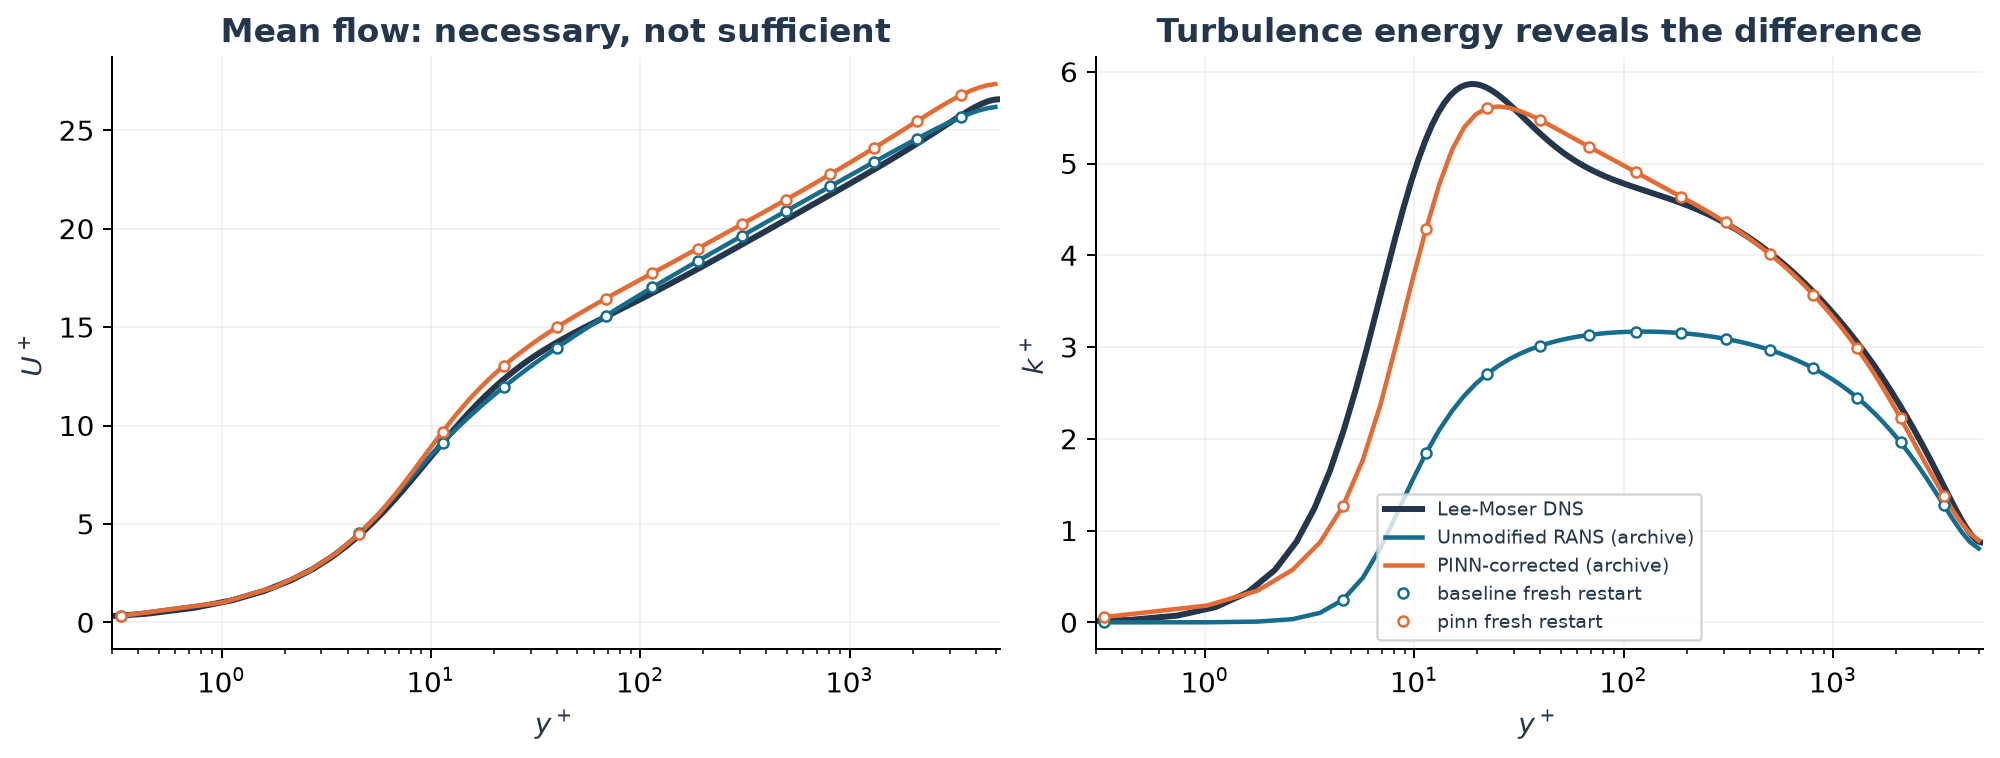

In [2]:
import sys
if str(ROOT) not in sys.path: sys.path.insert(0,str(ROOT))
from flowmllab.rans_closure import closure_features, relative_l2, cell_widths
k_dns = .5*stress[:,2:5].sum(axis=1)
rows=[]
for name,a in [('Actual baseline archive',baseline),('PINN-corrected archive',corrected)]:
    y=a[:,0]
    for column,ref,label in [(1,np.interp(y,dns[:,0],dns[:,2]),'U+'),
                             (2,np.interp(y,stress[:,0],k_dns),'k+')]:
        rows.append({'profile':name,'quantity':label,
                     'pointwise_relative_L2':relative_l2(a[:,column],ref),
                     'midpoint_weighted_relative_L2':relative_l2(a[:,column],ref,cell_widths(y))})
display(pd.DataFrame(rows))
display(Image(filename=str(EVIDENCE/'profiles.png')))
assert relative_l2(baseline[:,2],np.interp(baseline[:,0],stress[:,0],k_dns)) > .4

## 2. Recover the source features and target

The source c_k training script reads the corrected-case table. For faithful
reproduction retain that choice, rather than substituting a different field.
Inputs are $\nu_t/y$ and $\min(|(\nu+\nu_t)dU/dy|,0.995)$ in this normalization.
The original uses default first-order gradient endpoints. No log transform.

The full method also changes $\sigma_k$ and $C_{\omega2}$. In the k equation,
the modeled destruction is $0.09 C_k k\omega$. In the omega equation the
destruction is $C_{\omega2}\omega^2$ (no extra factor 0.075).

,y+,nut/y,capped_total_shear,Ck
0,0.329637,0.000037,0.995,0.000418
1,1.021874,0.000126,0.995,0.002051
2,1.783335,0.000734,0.995,0.009637
3,2.620942,0.002985,0.995,0.022133
4,3.542310,0.006316,0.995,0.035895


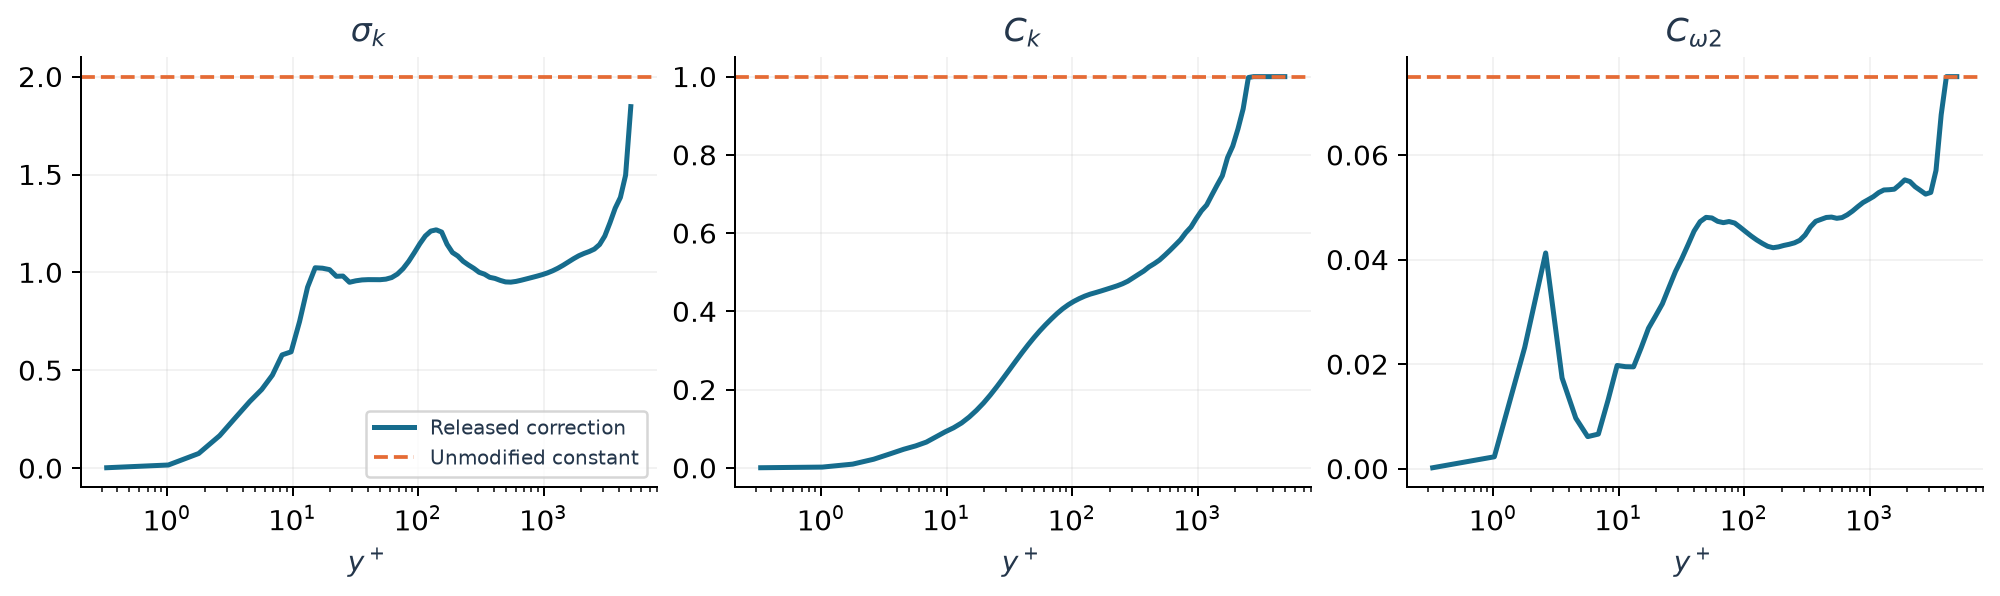

In [3]:
raw_features=closure_features(corrected)
yplus=corrected[:,0]*5200
assert raw_features.shape==(len(target),2)
assert np.isfinite(raw_features).all() and np.isfinite(target).all()
display(pd.DataFrame({'y+':yplus,'nut/y':raw_features[:,0],
                      'capped_total_shear':raw_features[:,1],'Ck':target}).head())
display(Image(filename=str(EVIDENCE/'coefficients.png')))

## 3. Original network protocol, independently readable implementation

The following compact teaching implementation preserves the executed source's
architecture, scaling, split, optimizer, batch order and epochs. The separately
retained `train_ck.json` records execution of the complete original script.
The source's scheduler is never stepped: learning rate remains 0.04.
Our explicit initialization seed is an orchestration addition.

**Reproduction caveat:** source MinMax scaling is fitted to the entire profile,
including test features. This preserves the historical protocol, but is not
the preprocessing rule to use for a new predictive experiment. The random-point
split is within one profile, not whole-case generalization.

{'epochs': 1000, 'seconds': 72.79452310001943, 'test_MSE': 0.00010168597646855102, 'test_relative_L2': 0.023041502500652178, 'complete_original_script_MSE': 0.00010168597646855102}
Difference from retained original-script MSE: 0.0


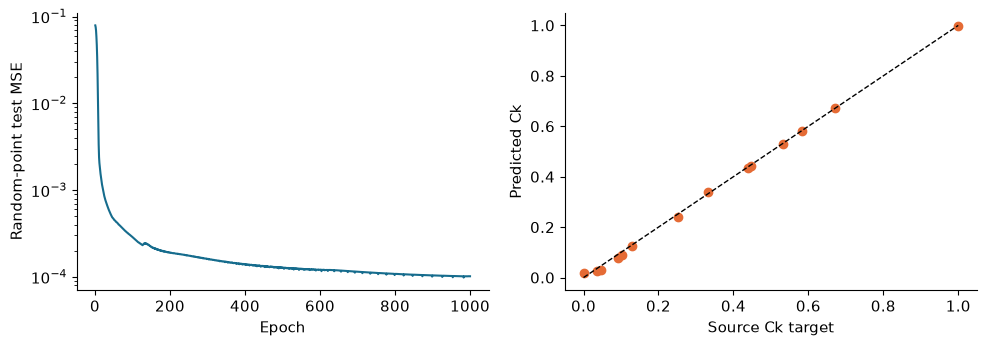

In [4]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
torch.manual_seed(42)
X=np.column_stack([MinMaxScaler().fit_transform(raw_features[:,i:i+1])[:,0]
                   for i in range(2)])
itr,ite=train_test_split(np.arange(len(X)),test_size=.2,shuffle=True,random_state=42)
class SourceNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.input=nn.Linear(2,10)
        self.hidden1=nn.Linear(10,10)
        self.hidden2=nn.Linear(10,1)
    def forward(self,x):
        return self.hidden2(torch.relu(self.hidden1(torch.relu(self.input(x)))))
net=SourceNet()
train=DataLoader(TensorDataset(torch.tensor(X[itr],dtype=torch.float32),
                              torch.tensor(target[itr,None],dtype=torch.float32)),
                 batch_size=1,shuffle=False)
test=DataLoader(TensorDataset(torch.tensor(X[ite],dtype=torch.float32),
                             torch.tensor(target[ite,None],dtype=torch.float32)),
                batch_size=1,shuffle=False)
optimizer=torch.optim.SGD(net.parameters(),lr=.04)
loss_fn=nn.MSELoss()
history=[]
started=time.perf_counter()
for epoch in range(1000):
    for xb,yb in train:
        optimizer.zero_grad()
        loss=loss_fn(net(xb),yb)
        loss.backward()
        optimizer.step()
    with torch.no_grad():
        history.append(sum(loss_fn(net(xb),yb).item() for xb,yb in test)/len(test))
with torch.no_grad(): prediction=net(torch.tensor(X[ite],dtype=torch.float32)).numpy()[:,0]
original=json.loads((EVIDENCE/'train_ck.json').read_text())
print({'epochs':1000,'seconds':time.perf_counter()-started,
       'test_MSE':history[-1],'test_relative_L2':relative_l2(prediction,target[ite]),
       'complete_original_script_MSE':original['test_mse']})
# Numerical libraries/platforms can differ; never silently claim bitwise equality.
print('Difference from retained original-script MSE:',abs(history[-1]-original['test_mse']))
assert np.isfinite(history).all() and history[-1]<.01
fig,ax=plt.subplots(1,2,figsize=(10,3.6))
ax[0].semilogy(np.arange(1,1001),history,color='#166c8d')
ax[0].set(xlabel='Epoch',ylabel='Random-point test MSE')
ax[1].plot(target[ite],prediction,'o',color='#e56b35')
ax[1].plot([0,1],[0,1],'k--',lw=1)
ax[1].set(xlabel='Source Ck target',ylabel='Predicted Ck')
plt.tight_layout(); plt.show()

## 4. Keep the stronger interpolation control

The next experiment is a **FlowMLLab adaptation**, not the source network:
log(nu_t/y), train-only StandardScaler, tanh and L-BFGS. Hold out 100 <= y+ <= 400.
This historically inspected interval is not a new blind experiment. PCHIP uses
wall position; it is a profile-specific control, not a local CFD closure.

,method,gap_relative_L2,gap_RMSE
0,PCHIP,0.014675,0.006775
1,Adapted MLP,0.041231,0.019034


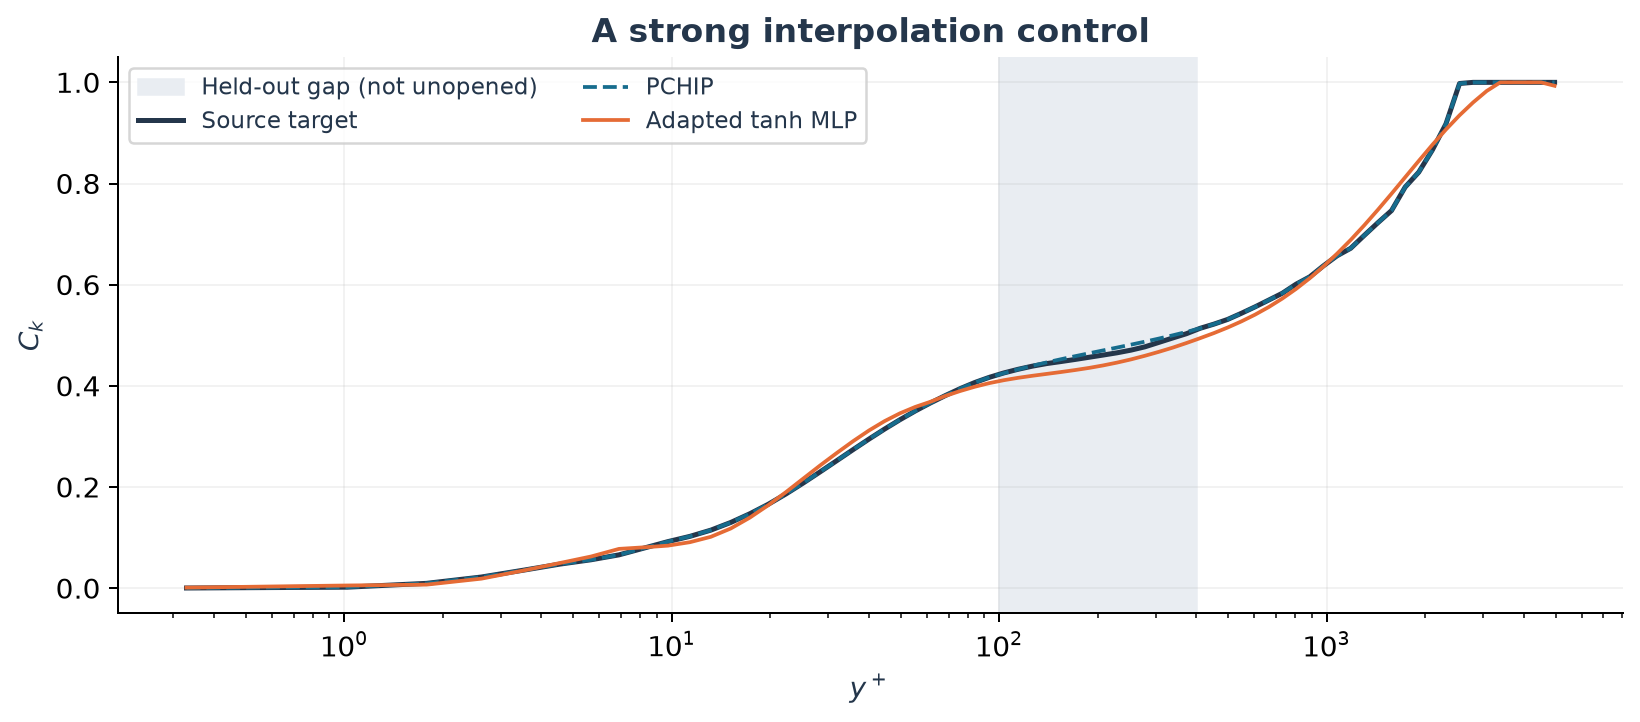

In [5]:
from scipy.interpolate import PchipInterpolator
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
hold=(yplus>=100)&(yplus<=400)
y,u,k,om,_=corrected.T
nut=k/om
adapted=np.c_[np.log10(np.maximum(nut/y,1e-12)),
              np.minimum(abs((1/5200+nut)*np.gradient(u,y,edge_order=2)),.995)]
mlp=make_pipeline(StandardScaler(),MLPRegressor(hidden_layer_sizes=(10,10),
                 activation='tanh',solver='lbfgs',alpha=1e-5,max_iter=5000,random_state=42))
mlp.fit(adapted[~hold],target[~hold])
pm=np.clip(mlp.predict(adapted),0,1)
pp=np.clip(PchipInterpolator(np.log10(yplus[~hold]),target[~hold])(np.log10(yplus)),0,1)
display(pd.DataFrame([{'method':name,'gap_relative_L2':relative_l2(p[hold],target[hold]),
                      'gap_RMSE':np.sqrt(np.mean((p[hold]-target[hold])**2))}
                     for name,p in [('PCHIP',pp),('Adapted MLP',pm)]]))
display(Image(filename=str(EVIDENCE/'gap.png')))

## 5. Inspect the freshly executed solver evidence

These runs execute source-assembled pyCALC-RANS from the author's saved states.
They are **restarts**, not cold-start or mesh-independence studies. The complete
NN solver uses the author's released pretrained checkpoints, not our new c_k fit.
The PINN-corrected 5200 case uses the released spatial correction tables.

The corrected `modify_case.py` must be assembled into the NN executable; the
archive's preassembled executable retains two older initialization bugs.
A reached iteration limit is not convergence, even if the residual is tiny.

,mode,grid,iteration,residual,threshold,converged,wall_shear,finite,restart
0,baseline,"[1, 70]",19999,3.119061e-13,1.000000e-14,False,1.000000,True,True
1,nn10000,"[1, 120]",39999,1.565909e-05,1.000000e-06,False,0.998672,True,True
2,nn5200,"[1, 70]",39999,2.385827e-03,1.000000e-06,False,1.001233,True,True
3,pinn,"[1, 70]",1,9.311862e-07,1.000000e-06,True,0.999993,True,True


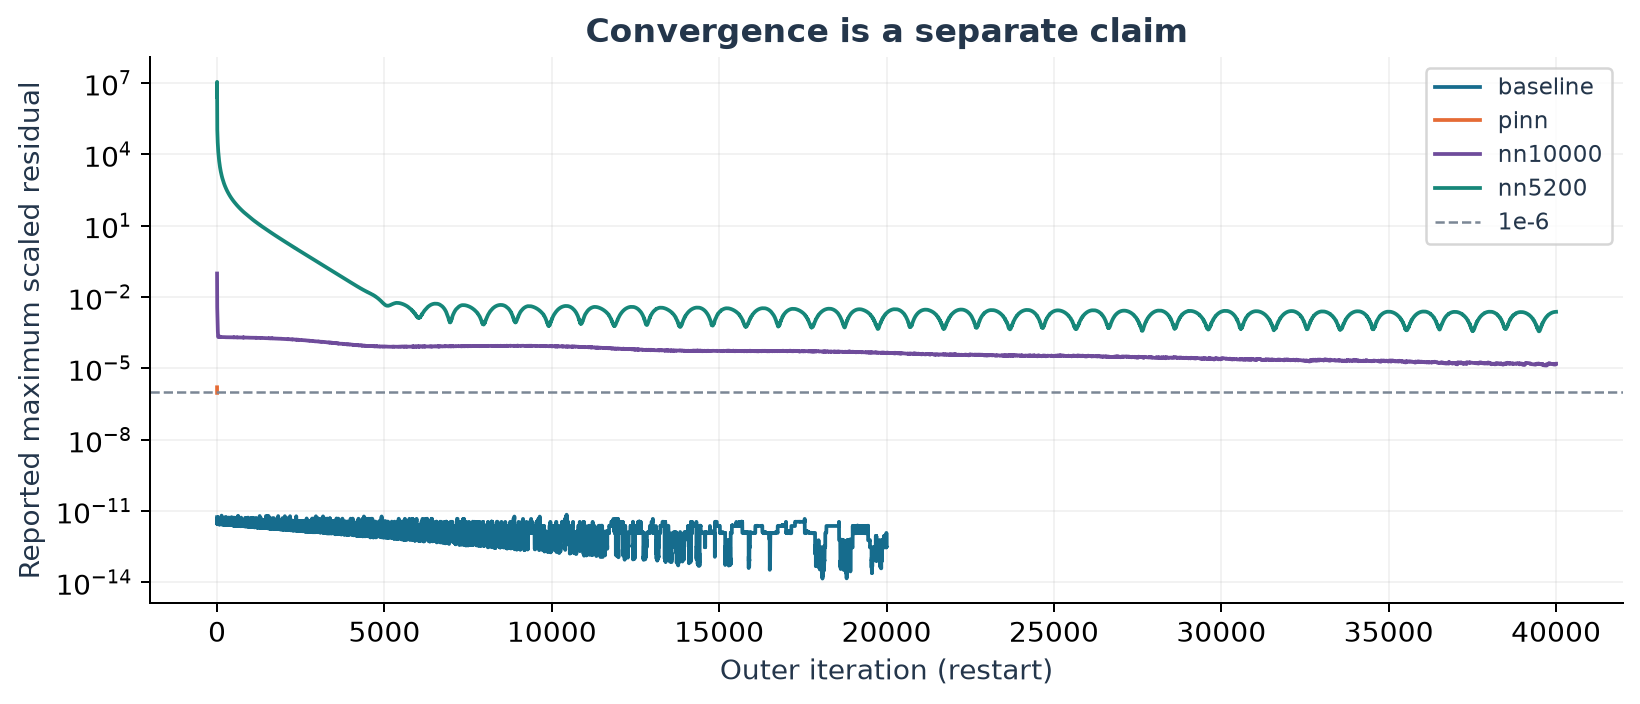

Known-case reproduction; not prospective blind validation or mesh independence


,max_absolute_difference,relative_L2,matches_released_target
c_k_pred_5200-plus-units-from-balance.txt,0.524585,0.107341,False
c_omega_2_pred_5200-plus-units-from-balance.txt,0.019786,0.138451,False
prand_k_5200-plus-units-from-balance-smooth.txt,0.298867,0.11863,False


The original balance script does not regenerate the bundled targets; full pipeline reproduction is NOT established.


In [6]:
summary=json.loads((EVIDENCE/'summary.json').read_text())
runs=[v for v in summary['runs'].values() if 'residual' in v]
display(pd.DataFrame(runs)[['mode','grid','iteration','residual','threshold',
                           'converged','wall_shear','finite','restart']])
assert all(r['finite'] for r in runs)
assert all(abs(r['wall_shear']-1)<.03 for r in runs)
display(Image(filename=str(EVIDENCE/'convergence.png')))
print(summary['claim_boundary'])
display(pd.DataFrame(summary['balance_regeneration']).T)
print('The original balance script does not regenerate the bundled targets; full pipeline reproduction is NOT established.')

## 6. Inverse PINN and the reproducibility boundary

The inverse PINN solves for the diffusion coefficient using DNS k, production
and dissipation. It is not the supervised network trained above. The original
long script resumes a supplied checkpoint and requests 200,000 epochs.
Consult the validation README for the exact status of that extended run;
loading its released outputs does not mean retraining it.

To repeat original-source operations, see `qa/prepare_week14_source.py` and
`qa/run_week14_upstream.py`. External code is downloaded into an isolated local
folder and pinned by SHA-256. Do not run arbitrary replacement archives.

**Attribution and permission:** the instructor reported Davidson's permission
in the shared conversation. The original written terms are not embedded here;
no general license or permission date is invented. Do not apply FlowMLLab's
license to upstream code, checkpoints or DNS. Derived teaching figures and
orchestration are identified separately.

**Submit:** baseline/corrected metrics, the original NN result, the gap control,
solver gates, and a bounded conclusion. Explain why a coefficient-fit improvement
does not by itself prove a more accurate or robust turbulence model.

References: Davidson (2026), DOI 10.1080/14685248.2026.2665148;
Davidson, pyCALC-RANS report; Lee and Moser (2015), DOI 10.1017/jfm.2015.268.

mode                                                                           inverse
seconds                                                                     1846.87714
executed_source_sha256               56e30f8e1be2ed6b3fbb4a69fa233fcec46b181faaf060...
torch                                                                       2.14.0+cpu
numpy                                                                            2.5.3
seed                                                                                42
epochs                                                                          200000
reported_final_total_loss                                                        231.0
reported_minimum_total_loss                                                       1.24
final_interior_loss                                                         230.633789
reference_diffusivity_relative_L2                                             0.007555
finite                                     

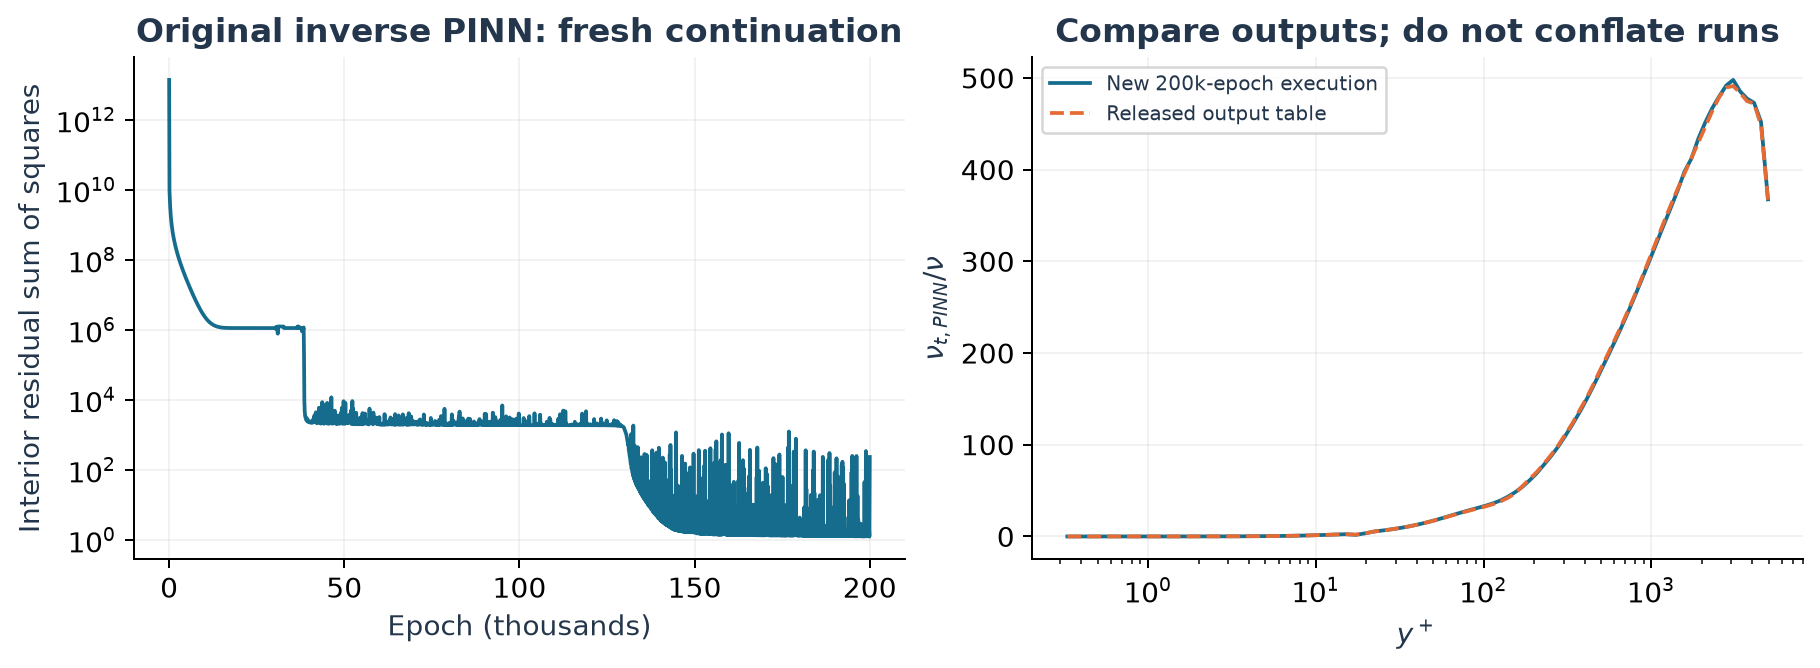

Additional constructed 5200 NN case, not an unchanged archive case:


mode                                                                 nn5200
seconds                                                          700.971019
executed_source_sha256    da245453c9032ee5f678d92bf7f9ca8ba48a3d1b1221e4...
torch                                                            2.14.0+cpu
numpy                                                                 2.5.3
seed                                                                     42
iteration                                                             39999
residual                                                           0.002386
threshold                                                          0.000001
converged                                                             False
restart                                                                True
grid                                                                [1, 70]
wall_shear                                                         1.001233
finite      

,case,U_relL2,k_relL2
0,Unmodified RANS (archive),0.017260,0.428492
1,PINN-corrected (archive),0.049881,0.089451
2,baseline fresh restart,0.017260,0.428492
3,pinn fresh restart,0.049881,0.089451
4,NN5200 assembled-case restart,0.040621,0.037777


In [7]:
if 'inverse' in summary['runs']:
    display(pd.Series(summary['runs']['inverse']))
    display(Image(filename=str(EVIDENCE/'inverse.png')))
if 'nn5200' in summary['runs']:
    print('Additional constructed 5200 NN case, not an unchanged archive case:')
    display(pd.Series(summary['runs']['nn5200']))
    display(pd.DataFrame(summary['profile_metrics']))